In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.core.pylabtools import figsize

df = pd.read_csv('datasets/nelsonplosser.csv')
df

,X.Y.m.d,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,wg.r,M,vel,bnd,sp
0,18601231,NaN,NaN,NaN,0.9,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
1,18611231,NaN,NaN,NaN,0.9,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,NaN,NaN
2,18621231,NaN,NaN,NaN,0.9,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN
3,18631231,NaN,NaN,NaN,1.0,NaN,NaN,NaN,37.0,NaN,NaN,NaN,NaN,NaN,NaN
4,18641231,NaN,NaN,NaN,1.0,NaN,NaN,NaN,48.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,19661231,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,68.34,308.0,1.76,4.75,85.26
107,19671231,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,68.80,331.8,1.72,4.95,91.93
108,19681231,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,70.51,361.6,1.72,5.93,98.70
109,19691231,724.7,929095.0,3577.0,110.7,81408.0,3.5,128.2,109.8,7775.0,70.81,385.2,1.73,6.54,97.84


In [75]:
print(df.columns)
print(df.shape)
df.isna().sum()

Index(['X.Y.m.d', 'gnp.r', 'gnp.n', 'gnp.pc', 'ip', 'emp', 'ur', 'gnp.p',
       'cpi', 'wg.n', 'wg.r', 'M', 'vel', 'bnd', 'sp'],
      dtype='object')
(111, 15)


X.Y.m.d     0
gnp.r      49
gnp.n      49
gnp.pc     49
ip          0
emp        30
ur         30
gnp.p      29
cpi         0
wg.n       40
wg.r       40
M          29
vel         9
bnd        40
sp         11
dtype: int64

In [76]:
df = df[df['X.Y.m.d'] >= 19090000]
df.isna().sum()

X.Y.m.d    0
gnp.r      0
gnp.n      0
gnp.pc     0
ip         0
emp        0
ur         0
gnp.p      0
cpi        0
wg.n       0
wg.r       0
M          0
vel        0
bnd        0
sp         0
dtype: int64

In [77]:
df.head()

,X.Y.m.d,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,wg.r,M,vel,bnd,sp
49,19091231,116.8,33400.0,1291.0,10.0,35072.0,5.1,29.1,28.0,599.0,21.39,12.68,2.19,3.77,9.71
50,19101231,120.1,35300.0,1300.0,10.6,35762.0,5.9,29.9,29.0,651.0,22.45,13.34,2.17,3.80,9.35
51,19111231,123.2,35800.0,1312.0,10.2,36179.0,6.7,29.7,29.0,632.0,21.79,14.12,2.07,3.90,9.24
52,19121231,130.2,39400.0,1366.0,11.7,37433.0,4.6,30.9,30.0,651.0,21.70,15.13,2.12,3.90,9.53
53,19131231,131.4,39600.0,1351.0,12.5,38298.0,4.3,31.1,29.7,689.0,23.20,15.73,2.15,4.00,8.51


### Exploratory Data Analysis

In [78]:
df['year'] = df.loc[:, 'X.Y.m.d'].astype(str)
df['year'] = df['year'].apply(lambda x: x[:4]).astype(int)
df.index = df['year']
df.drop(['year', 'X.Y.m.d'], axis=1, inplace=True)
df

/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2051193254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df.loc[:, 'X.Y.m.d'].astype(str)
/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2051193254.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['year'].apply(lambda x: x[:4]).astype(int)
/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2051193254.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,wg.r,M,vel,bnd,sp
year,,,,,,,,,,,,,,
1909,116.8,33400.0,1291.0,10.0,35072.0,5.1,29.1,28.0,599.0,21.39,12.68,2.19,3.77,9.71
1910,120.1,35300.0,1300.0,10.6,35762.0,5.9,29.9,29.0,651.0,22.45,13.34,2.17,3.80,9.35
1911,123.2,35800.0,1312.0,10.2,36179.0,6.7,29.7,29.0,632.0,21.79,14.12,2.07,3.90,9.24
1912,130.2,39400.0,1366.0,11.7,37433.0,4.6,30.9,30.0,651.0,21.70,15.13,2.12,3.90,9.53
1913,131.4,39600.0,1351.0,12.5,38298.0,4.3,31.1,29.7,689.0,23.20,15.73,2.15,4.00,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,68.34,308.00,1.76,4.75,85.26
1967,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,68.80,331.80,1.72,4.95,91.93
1968,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,70.51,361.60,1.72,5.93,98.70


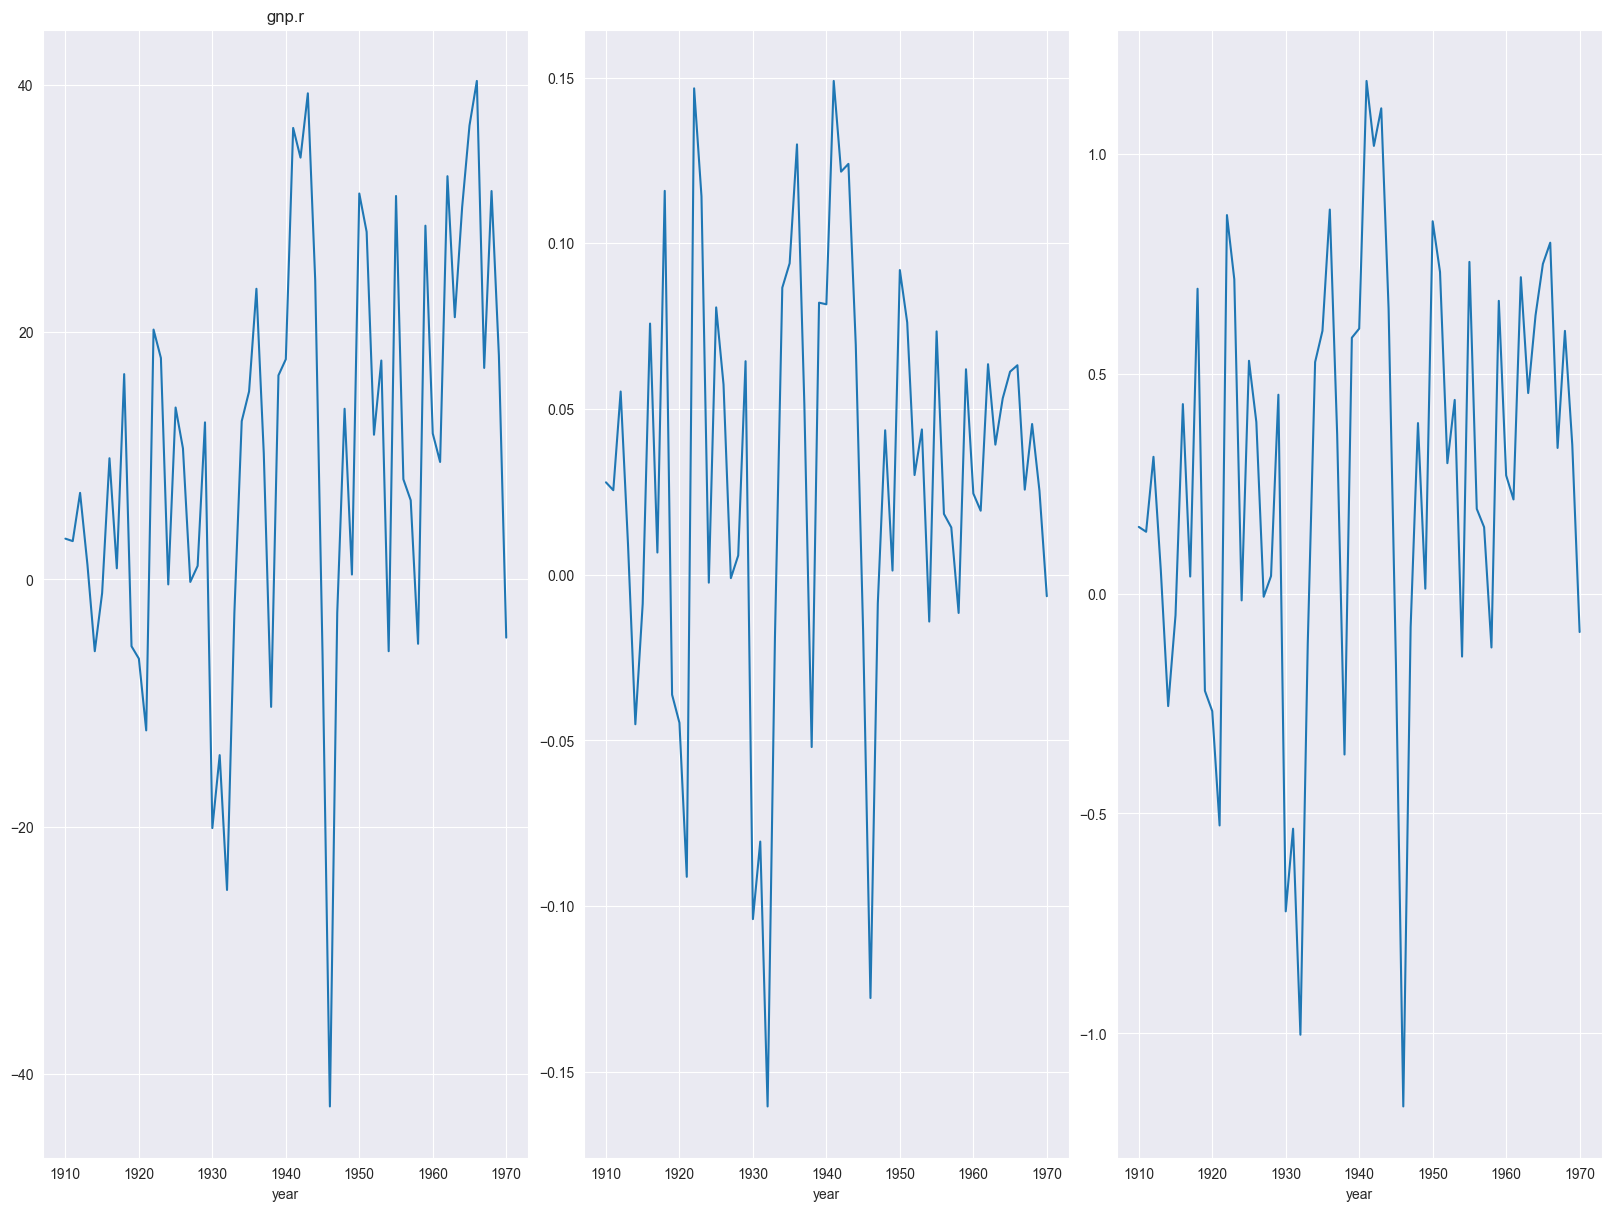

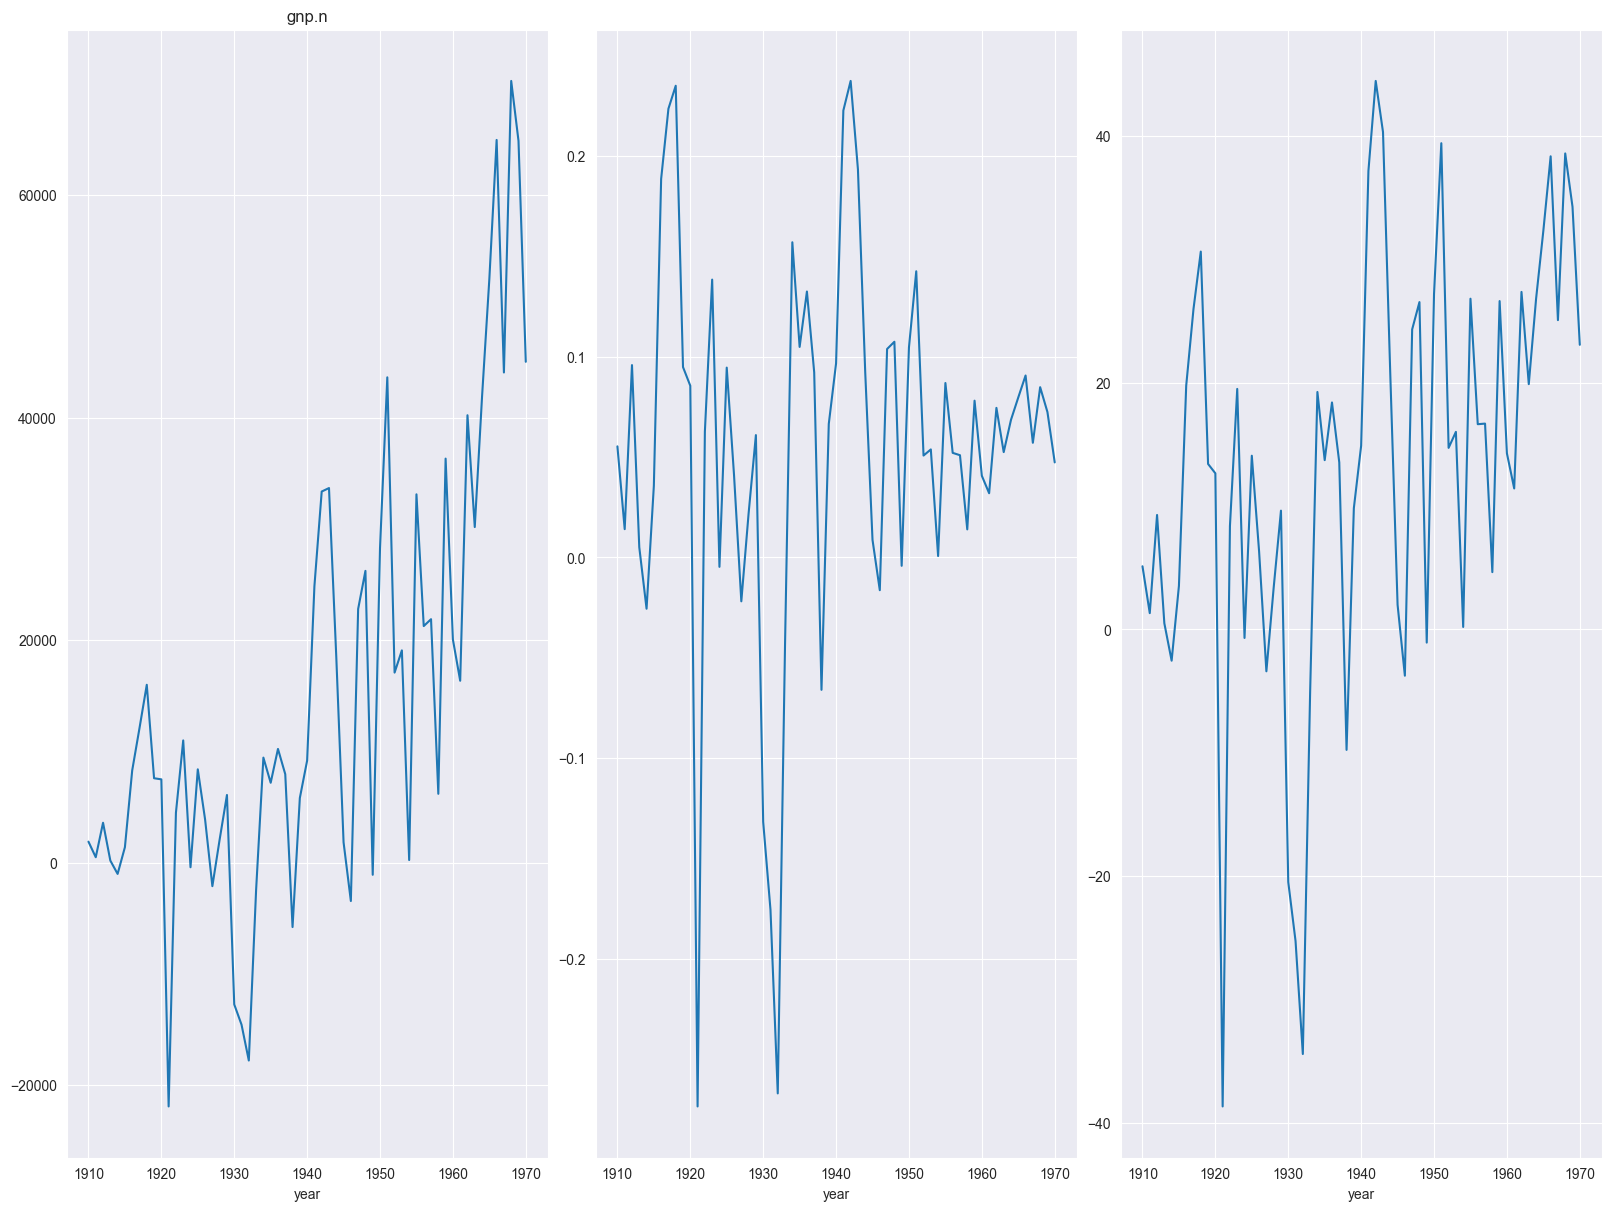

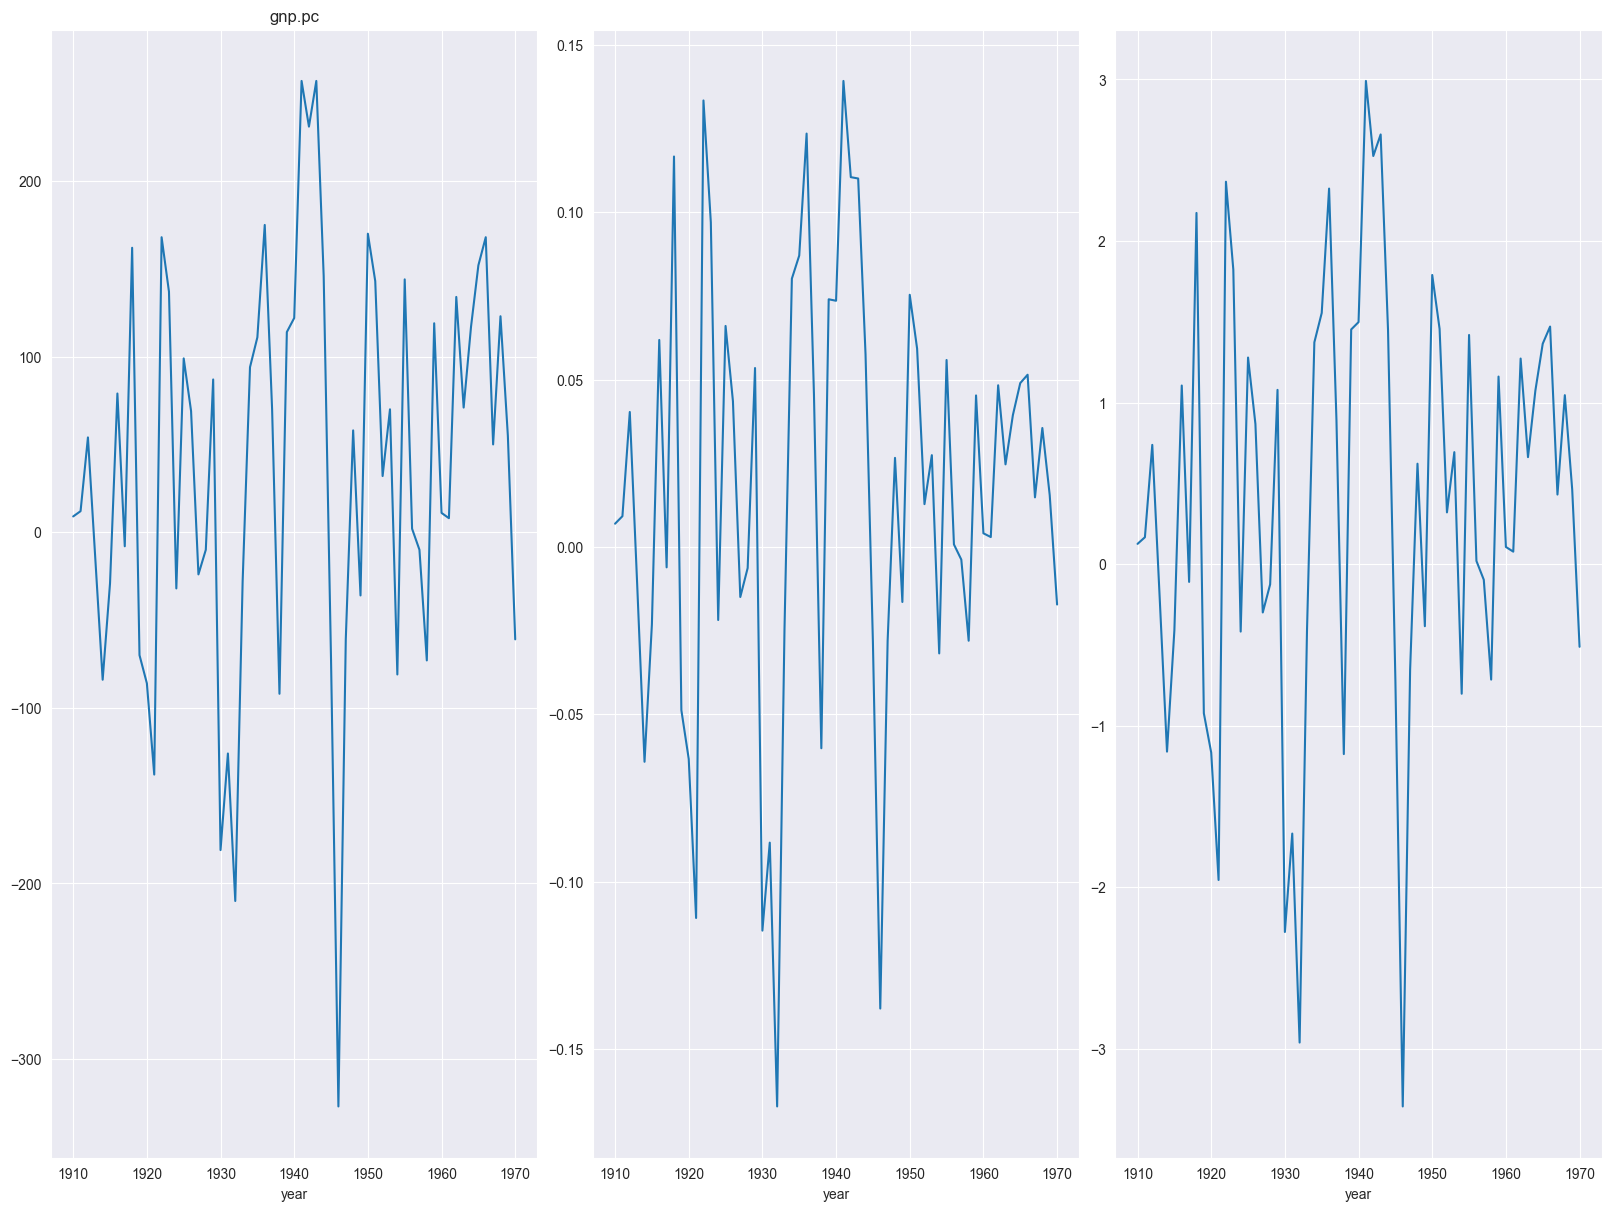

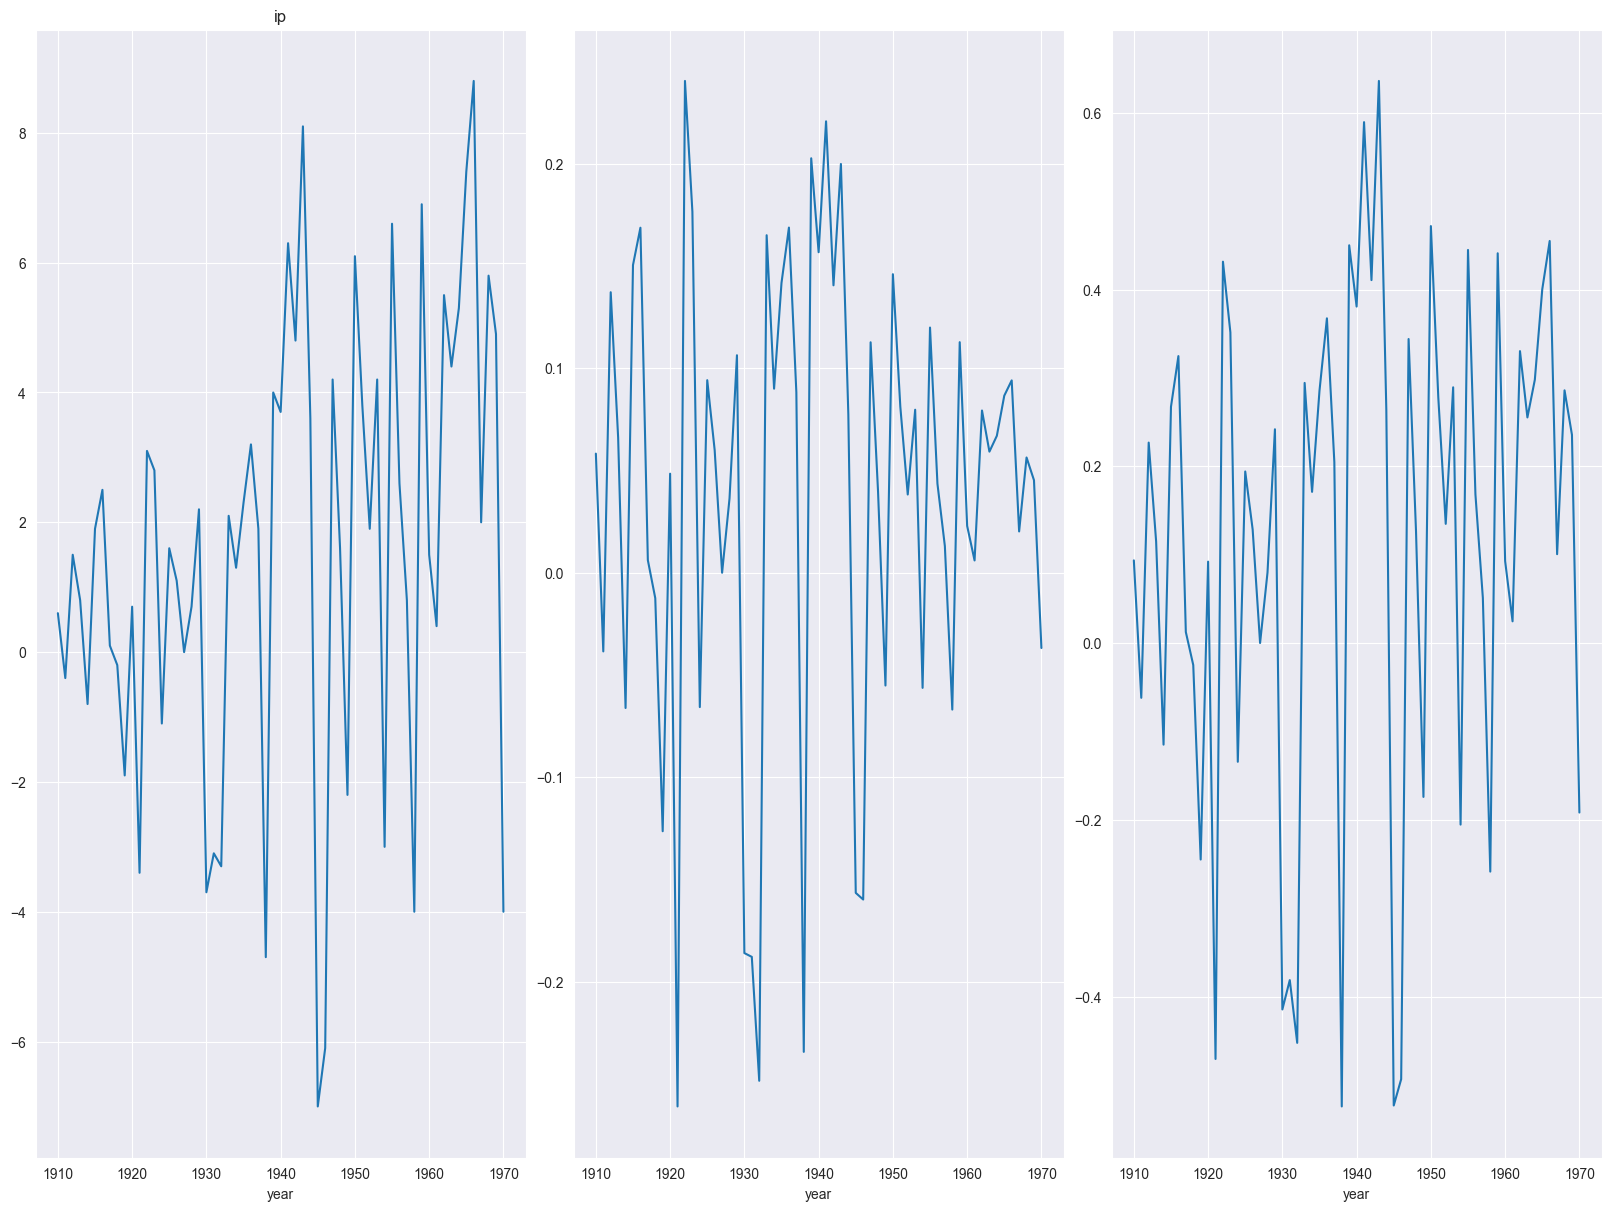

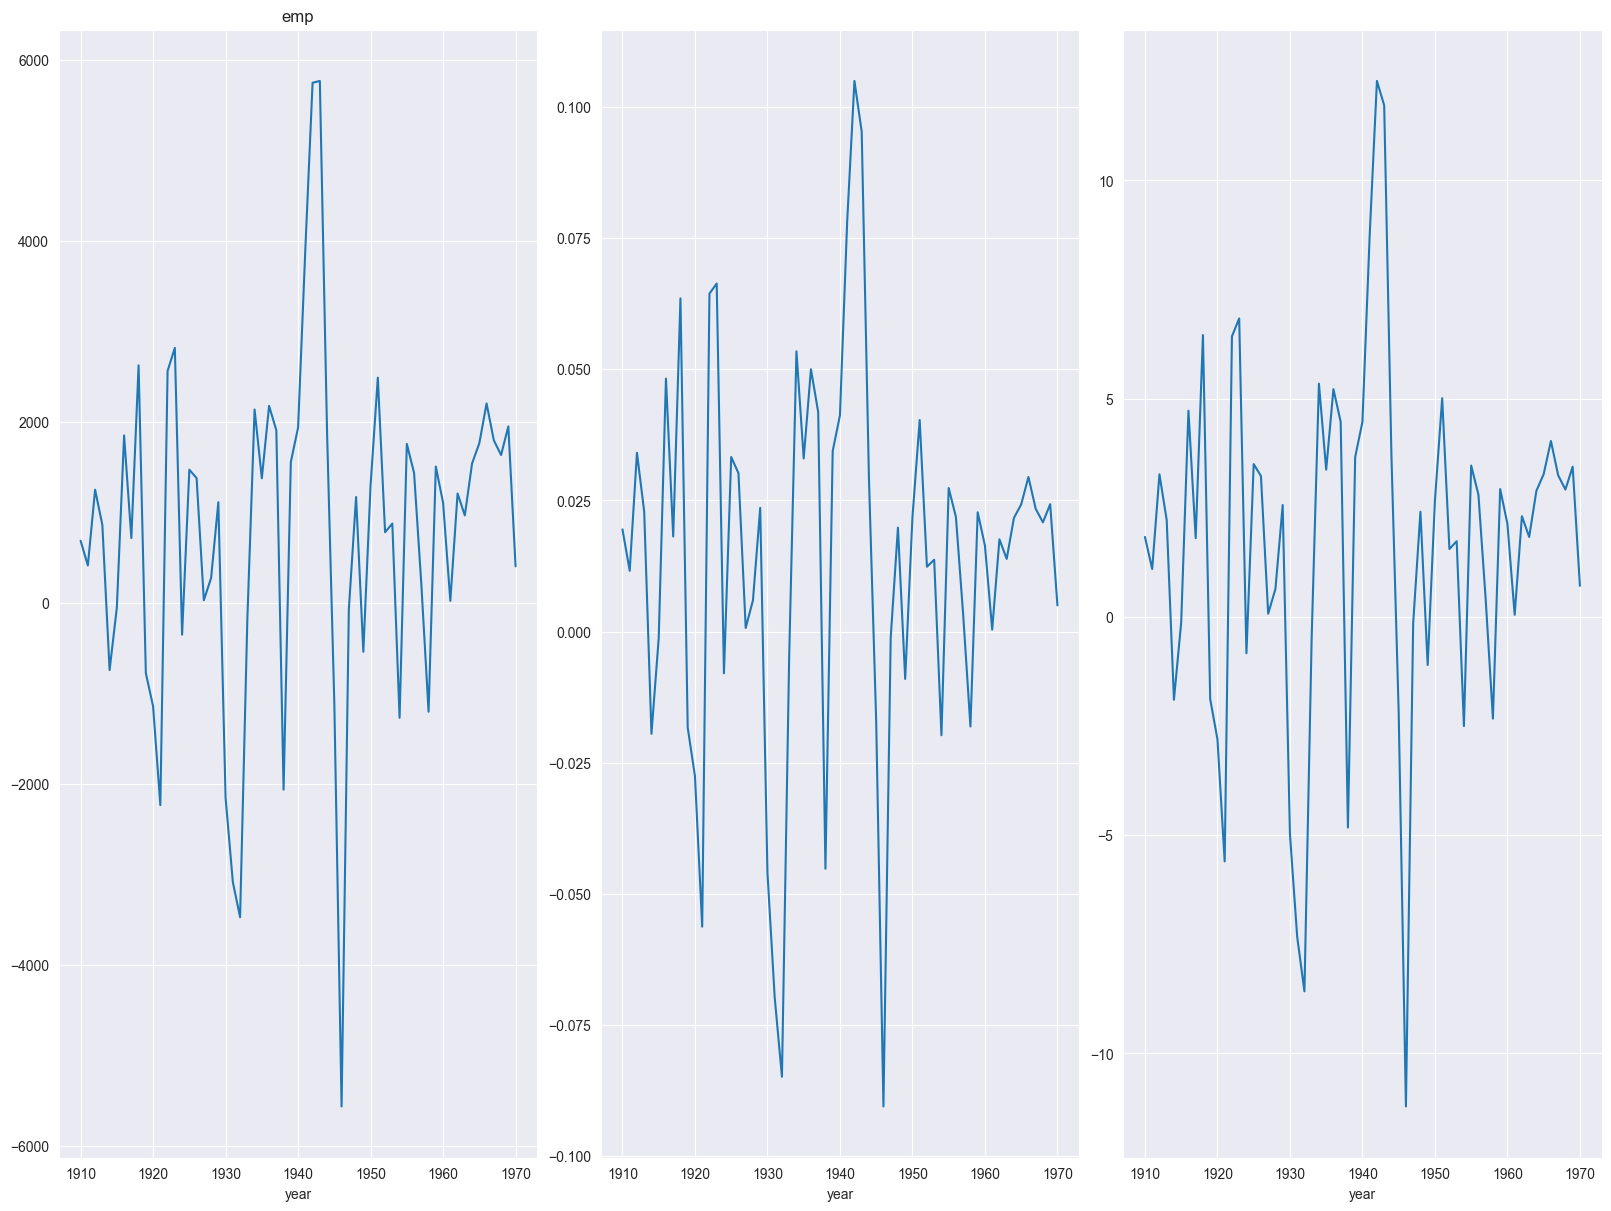

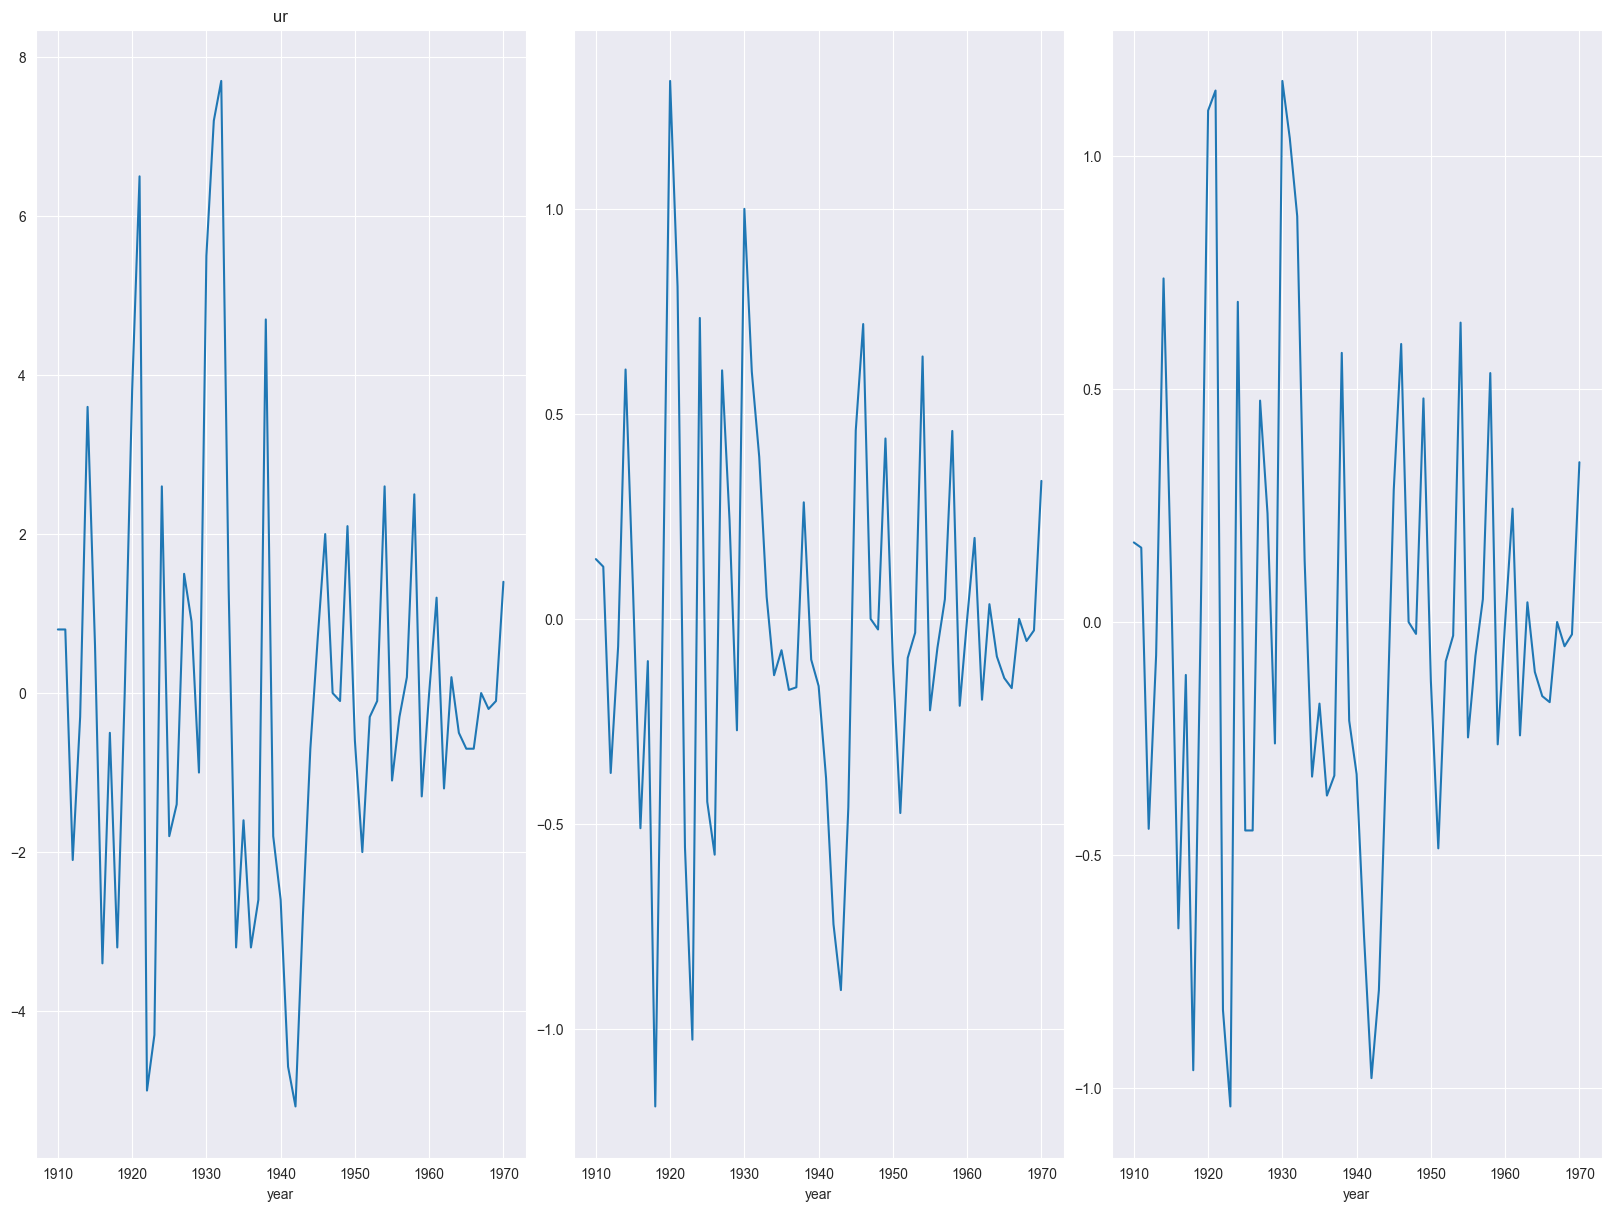

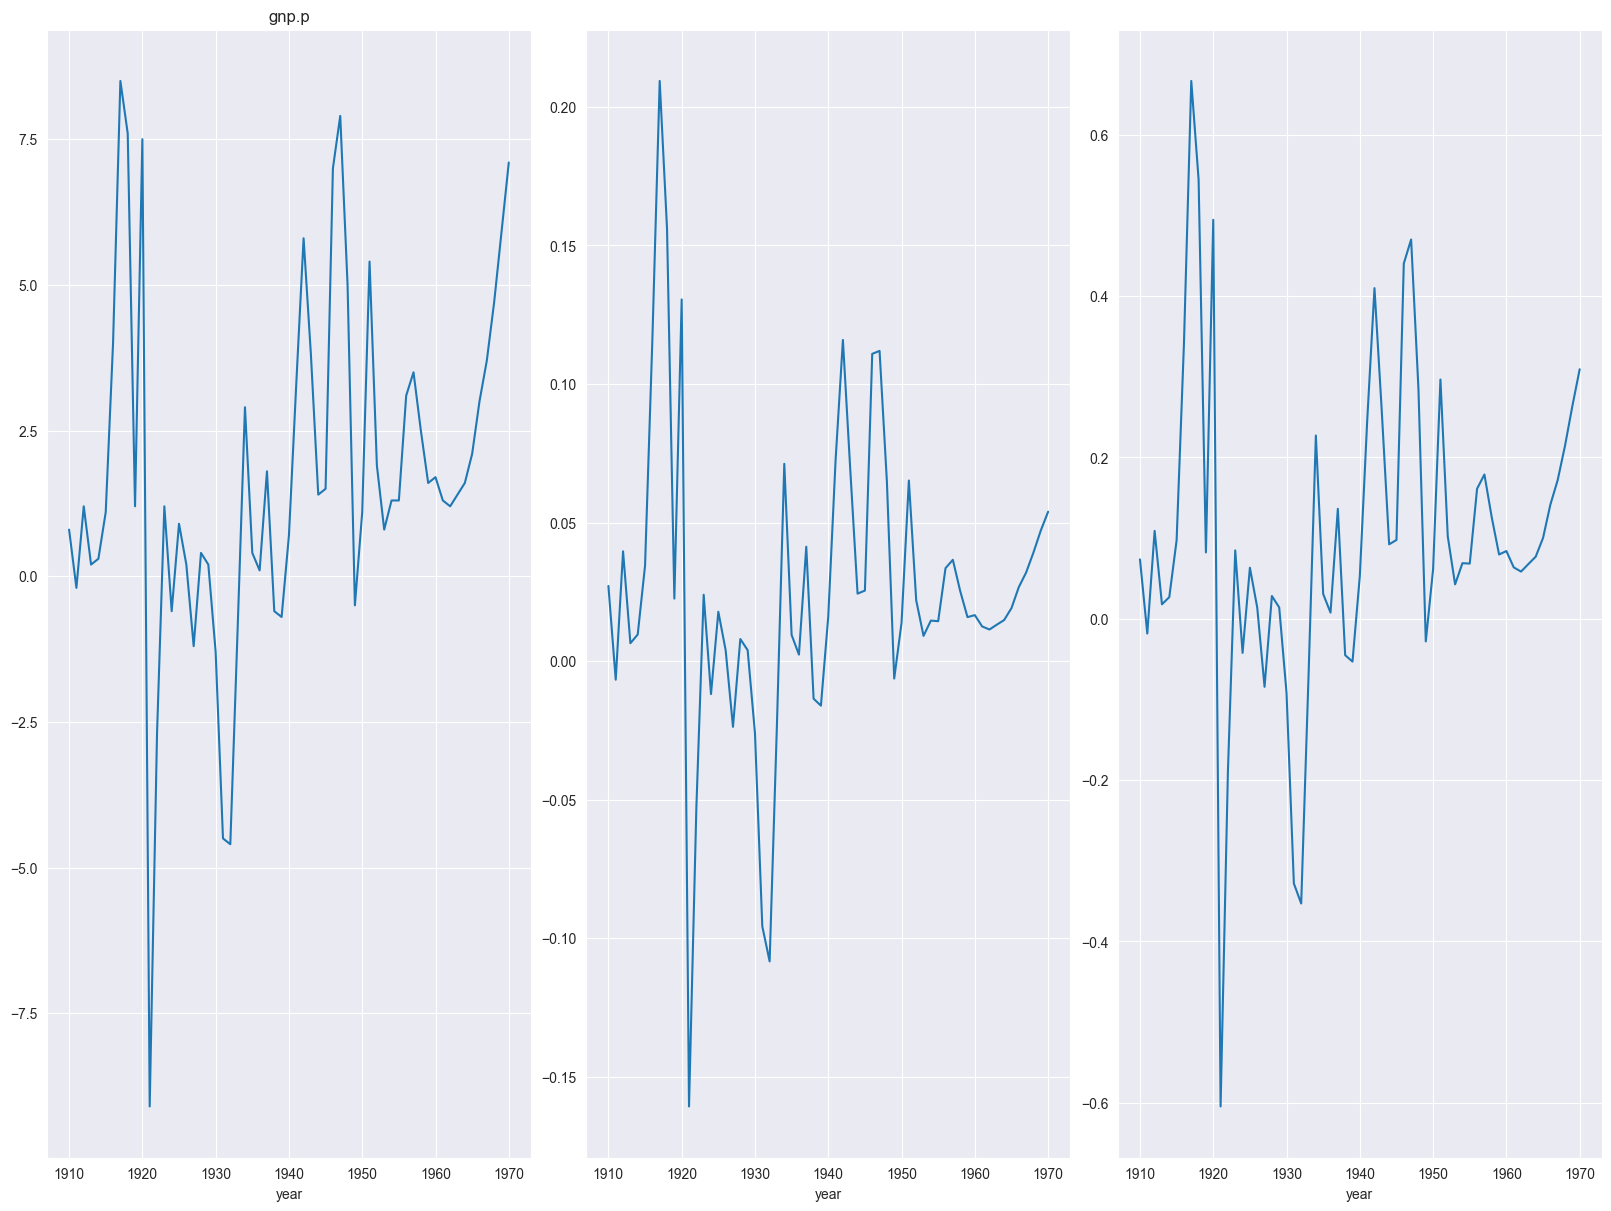

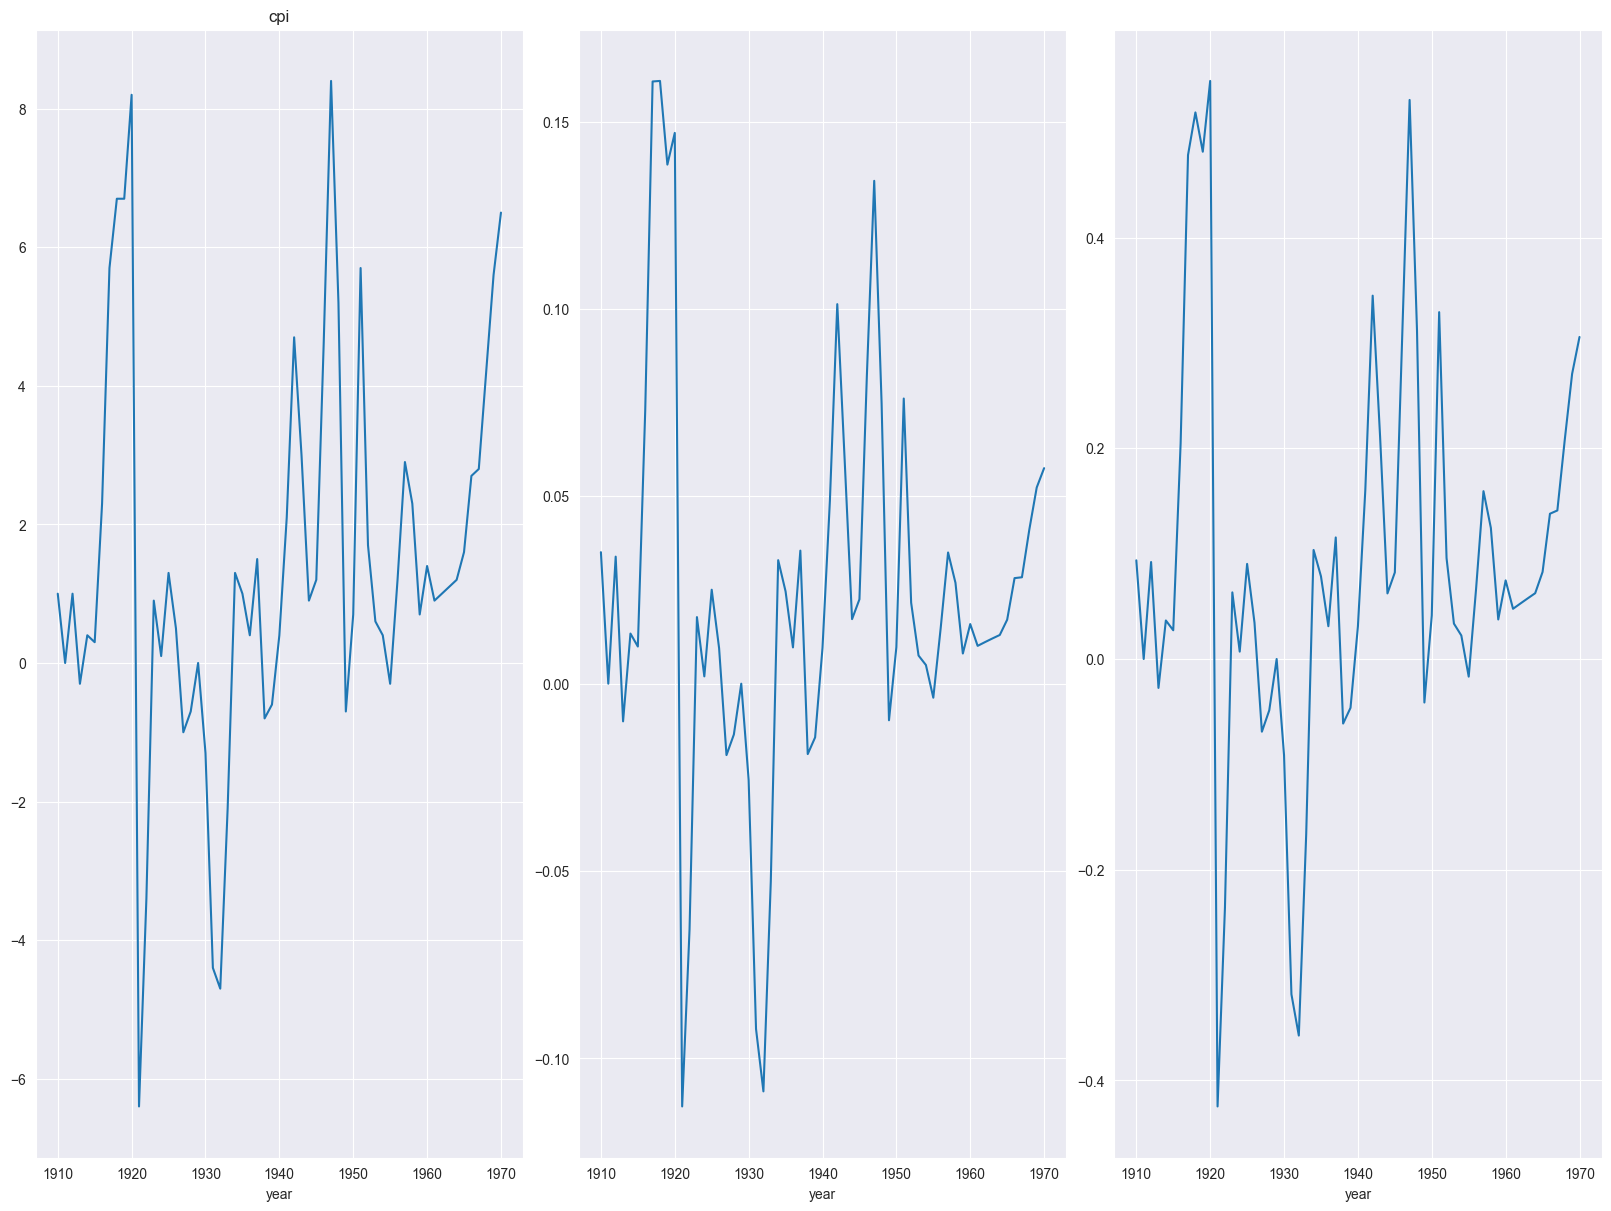

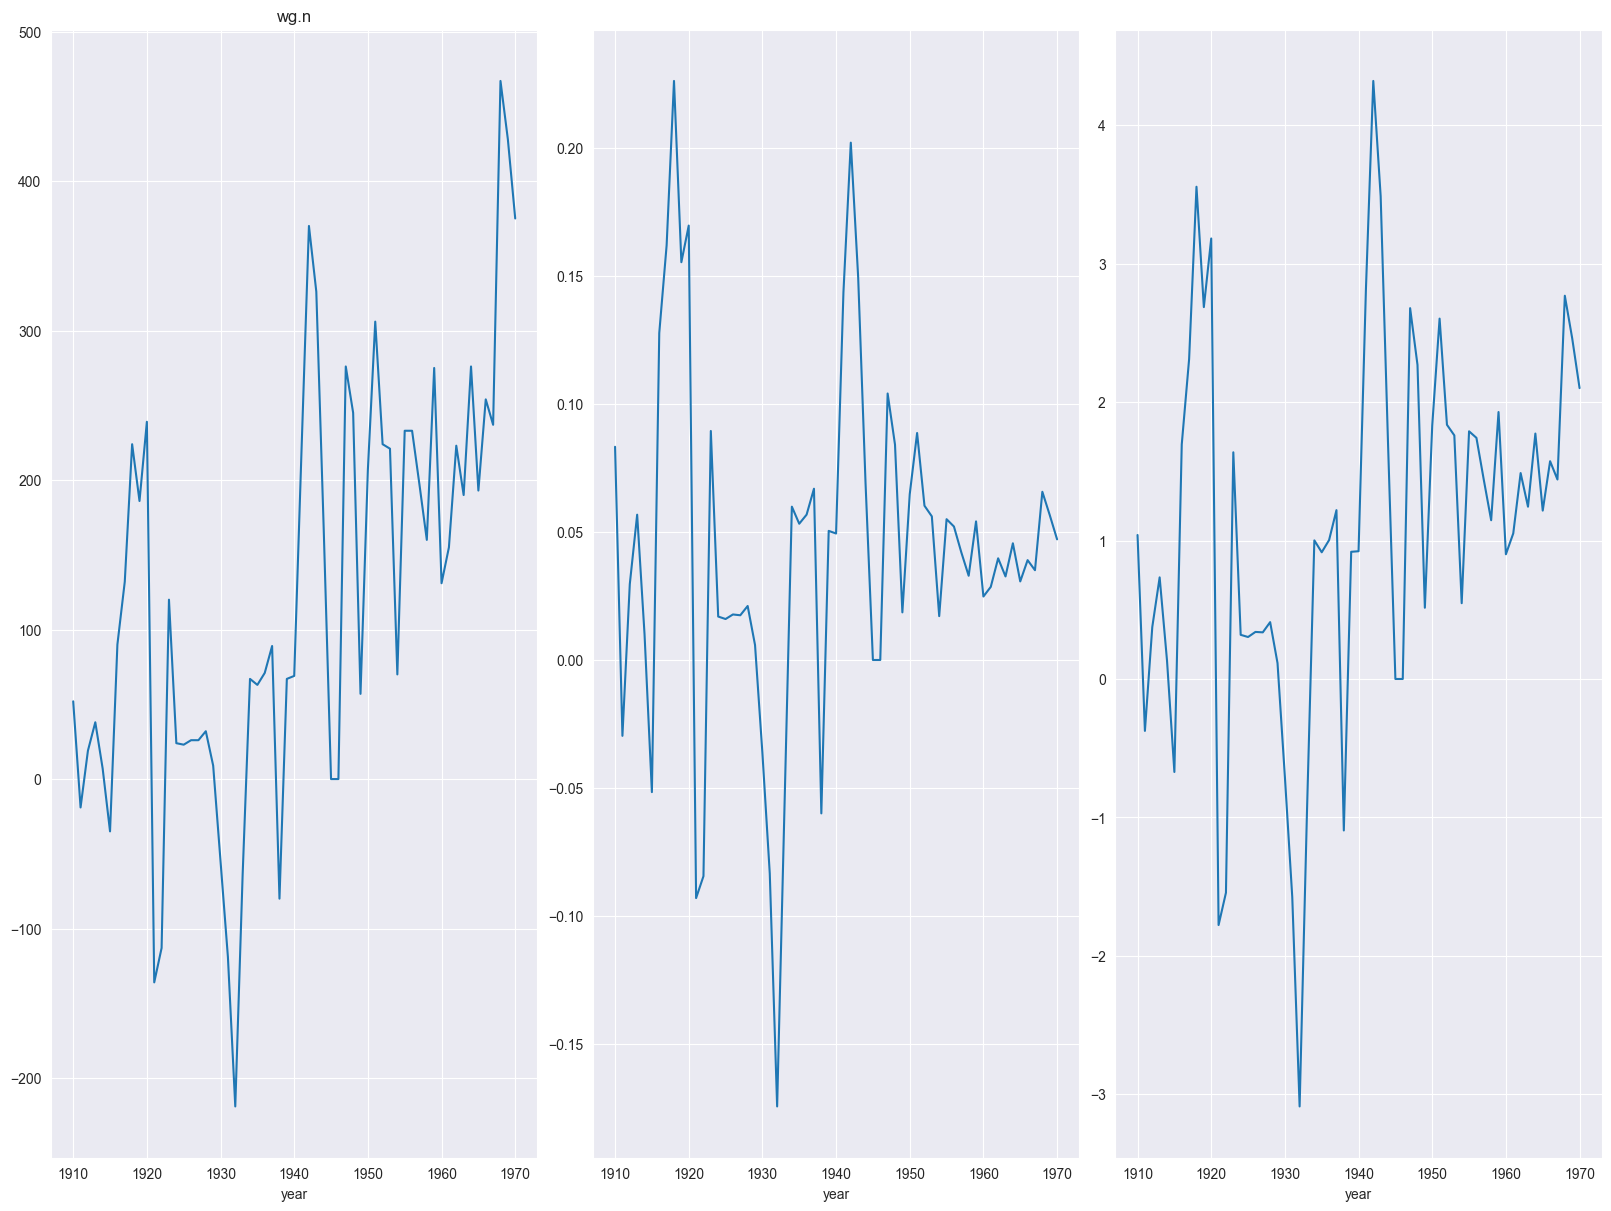

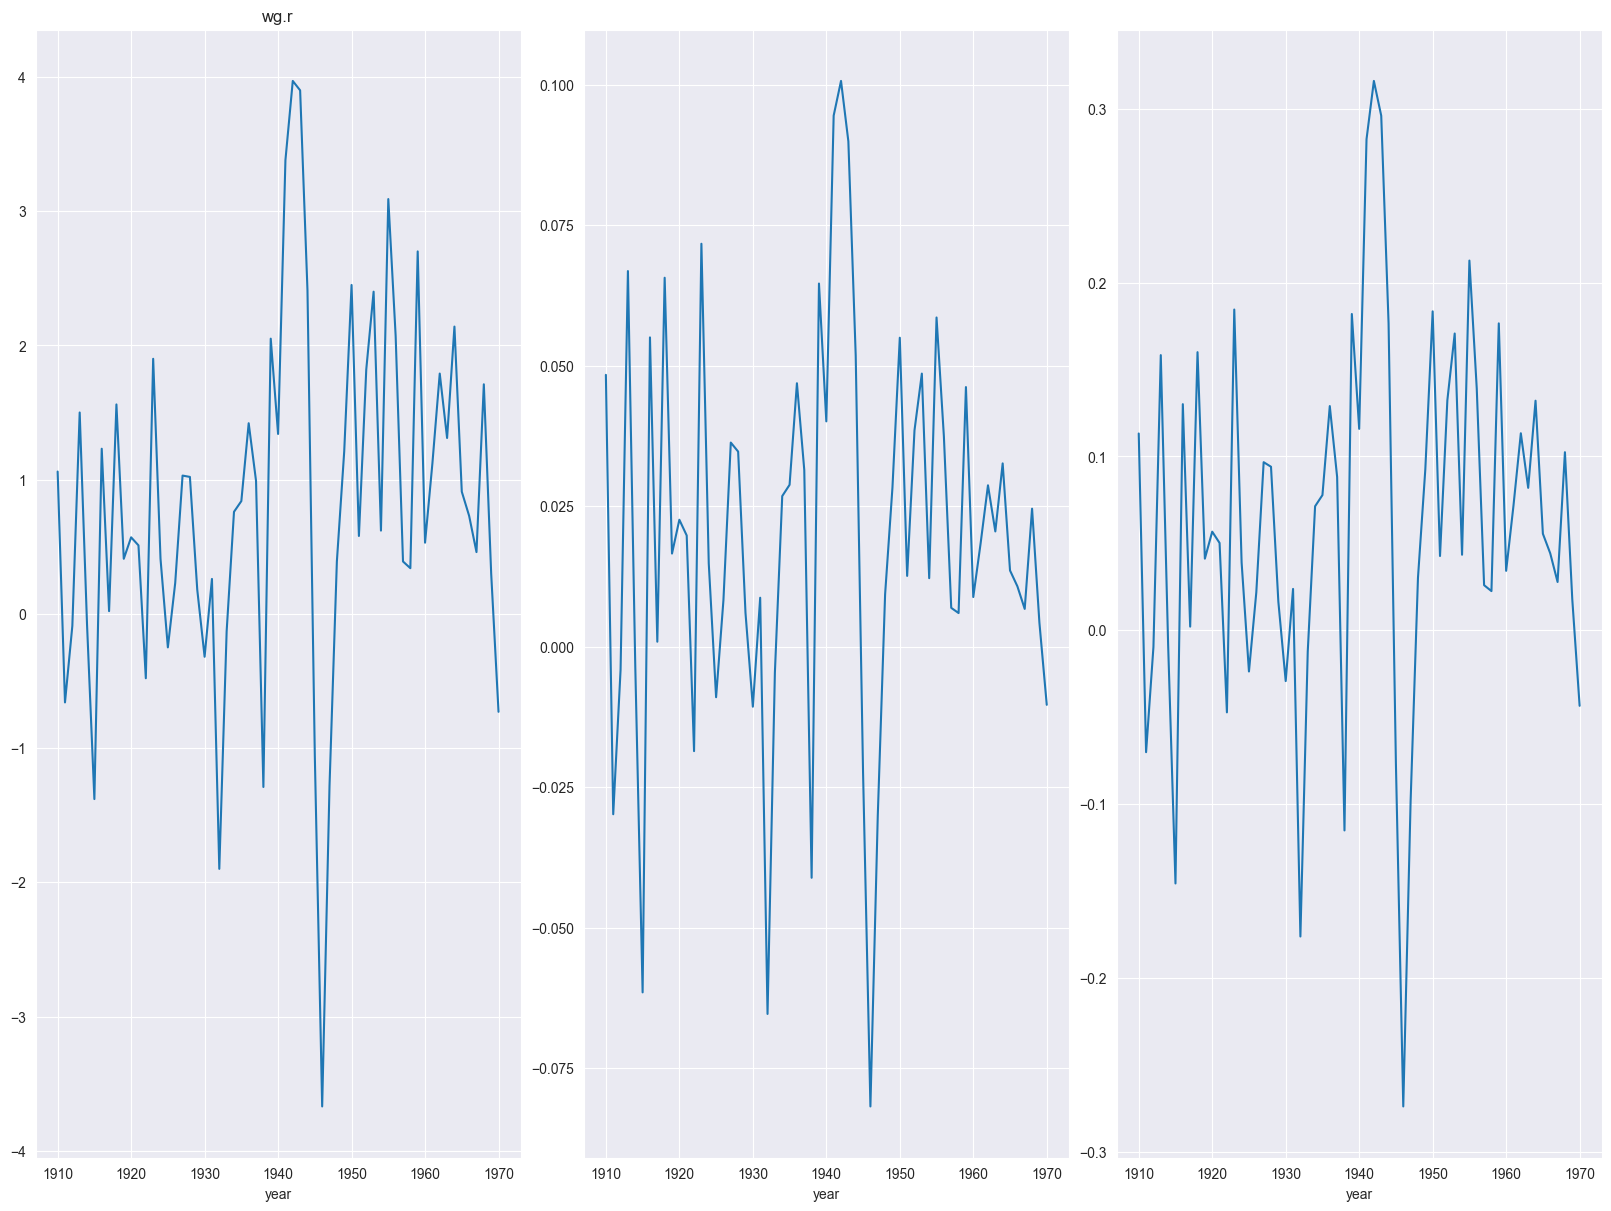

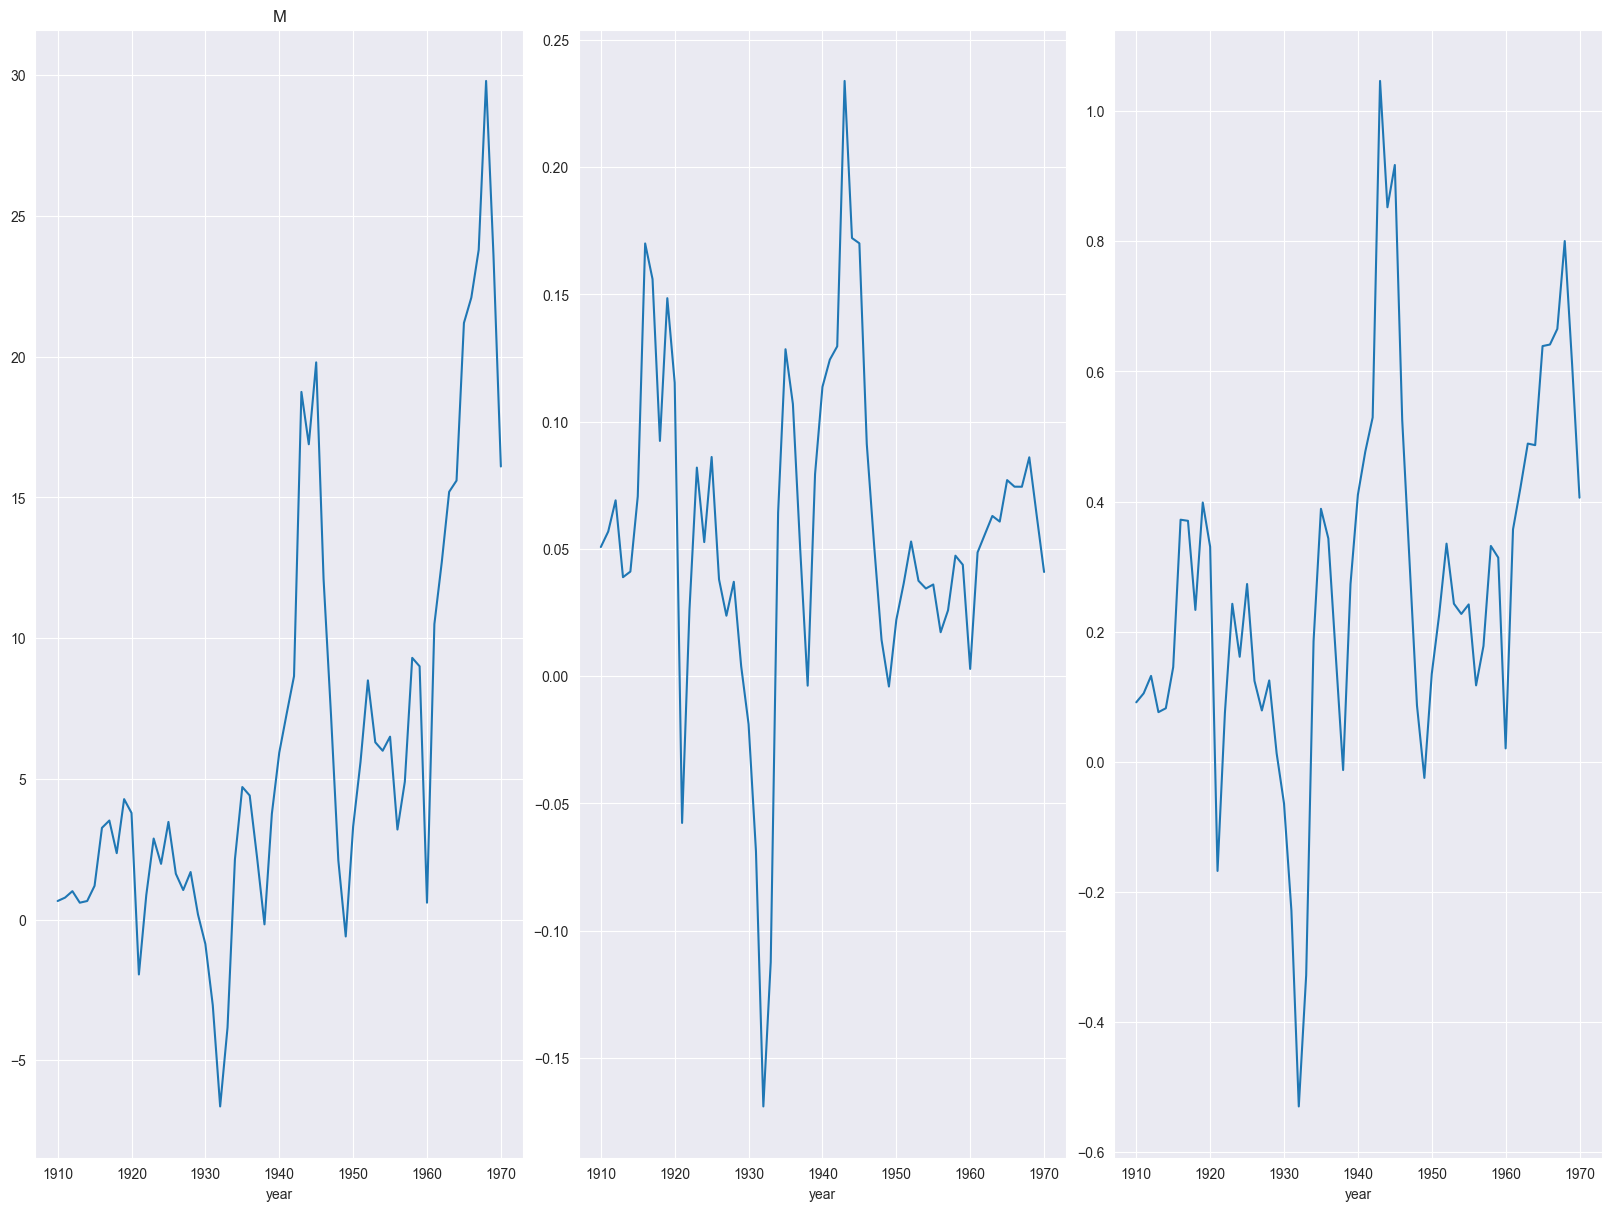

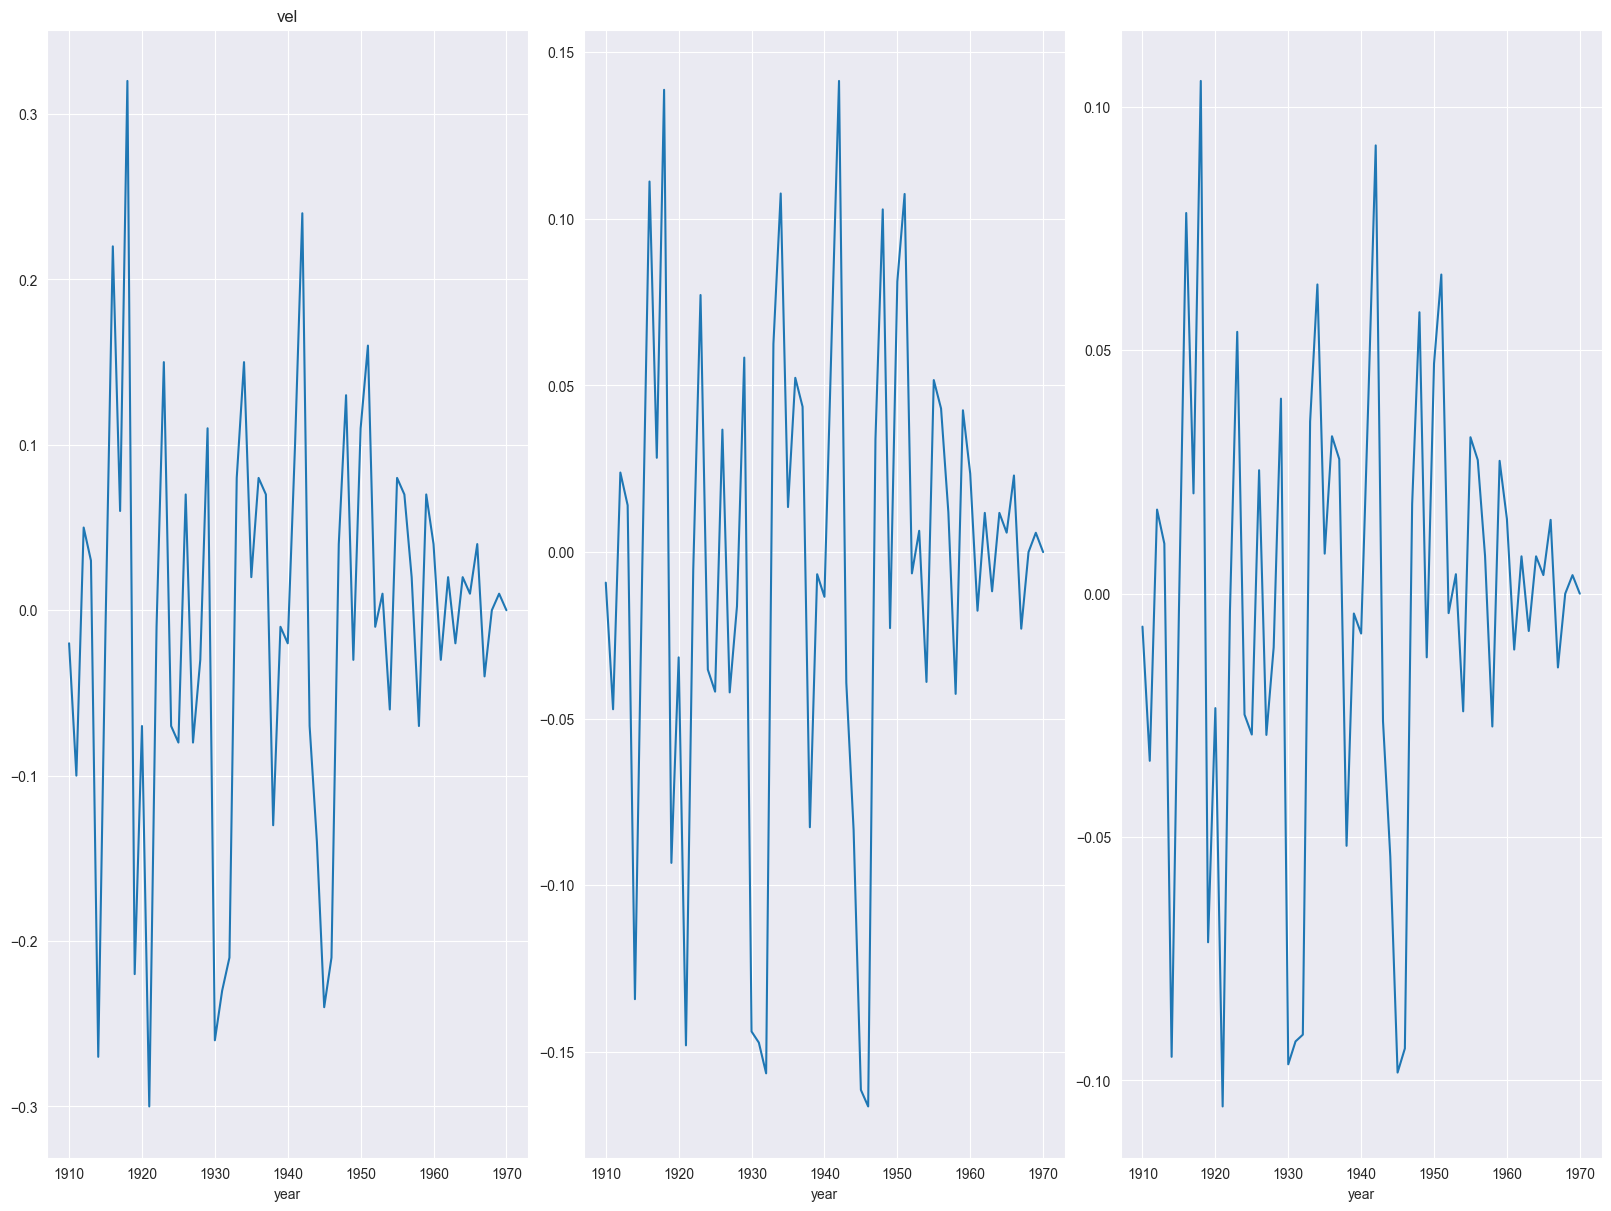

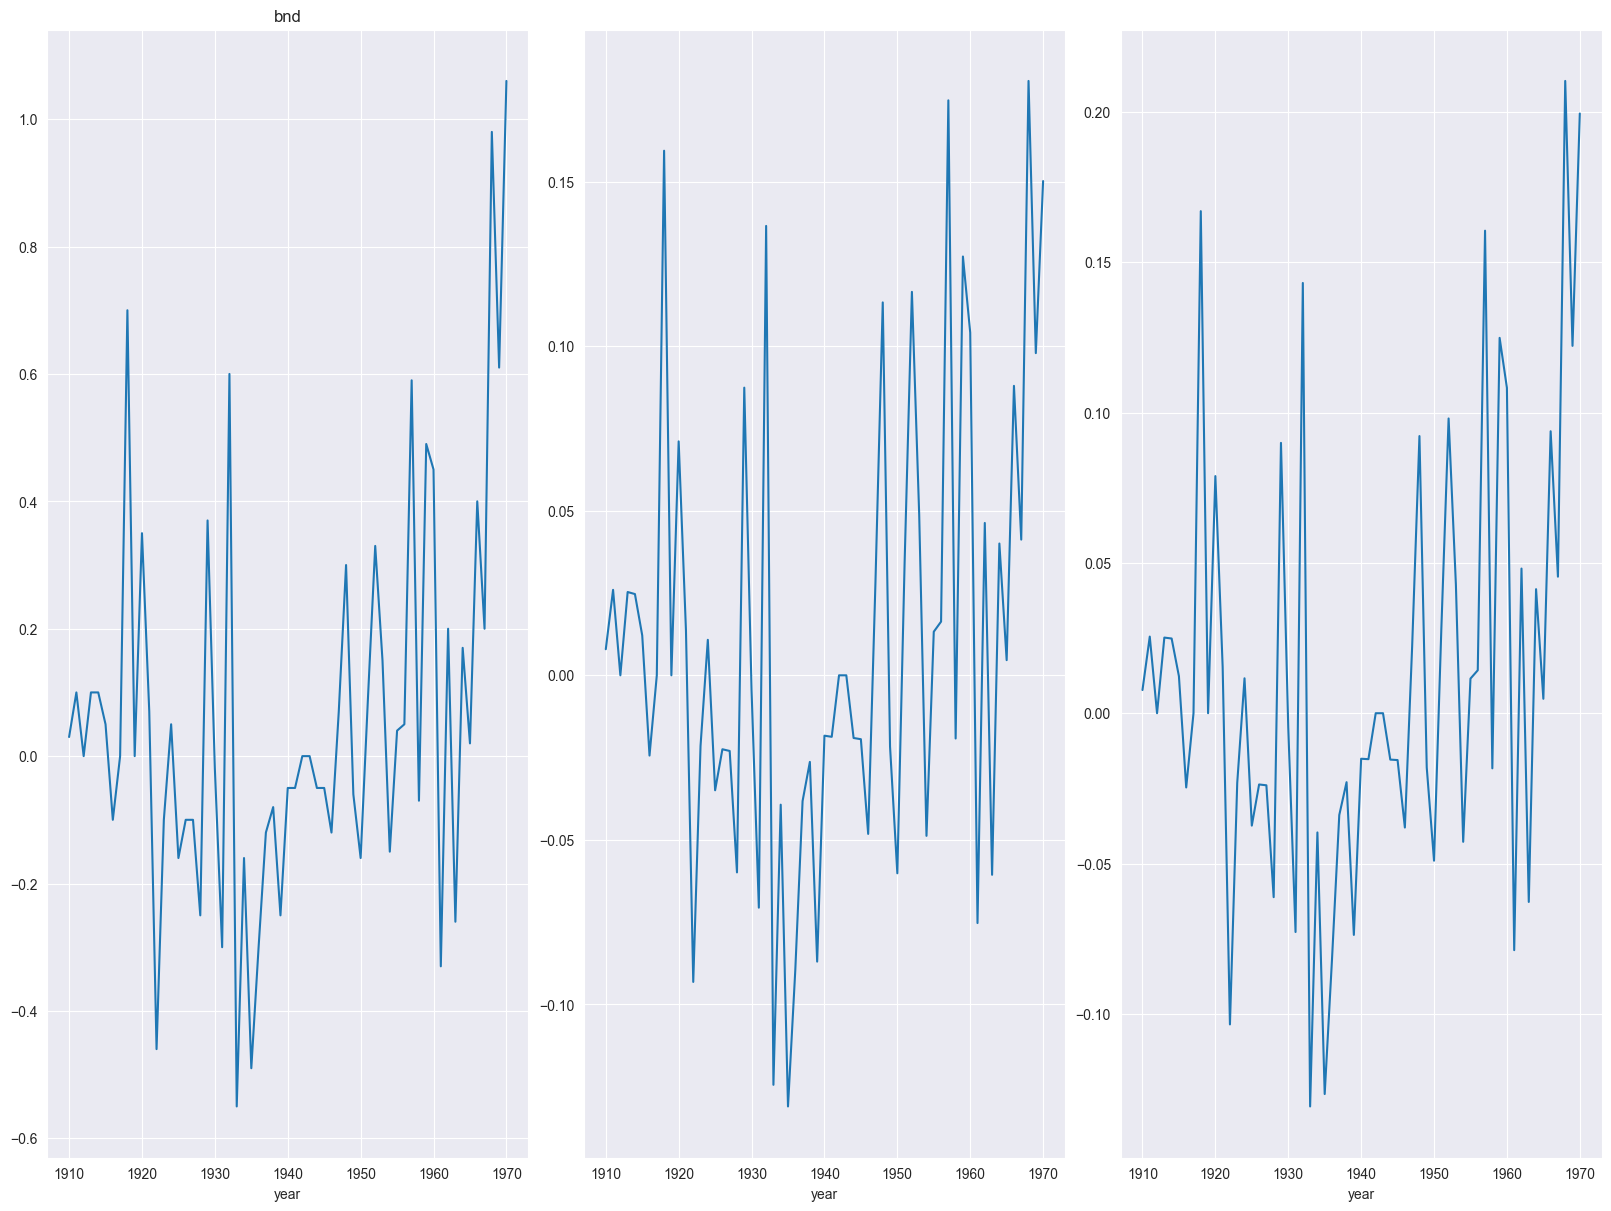

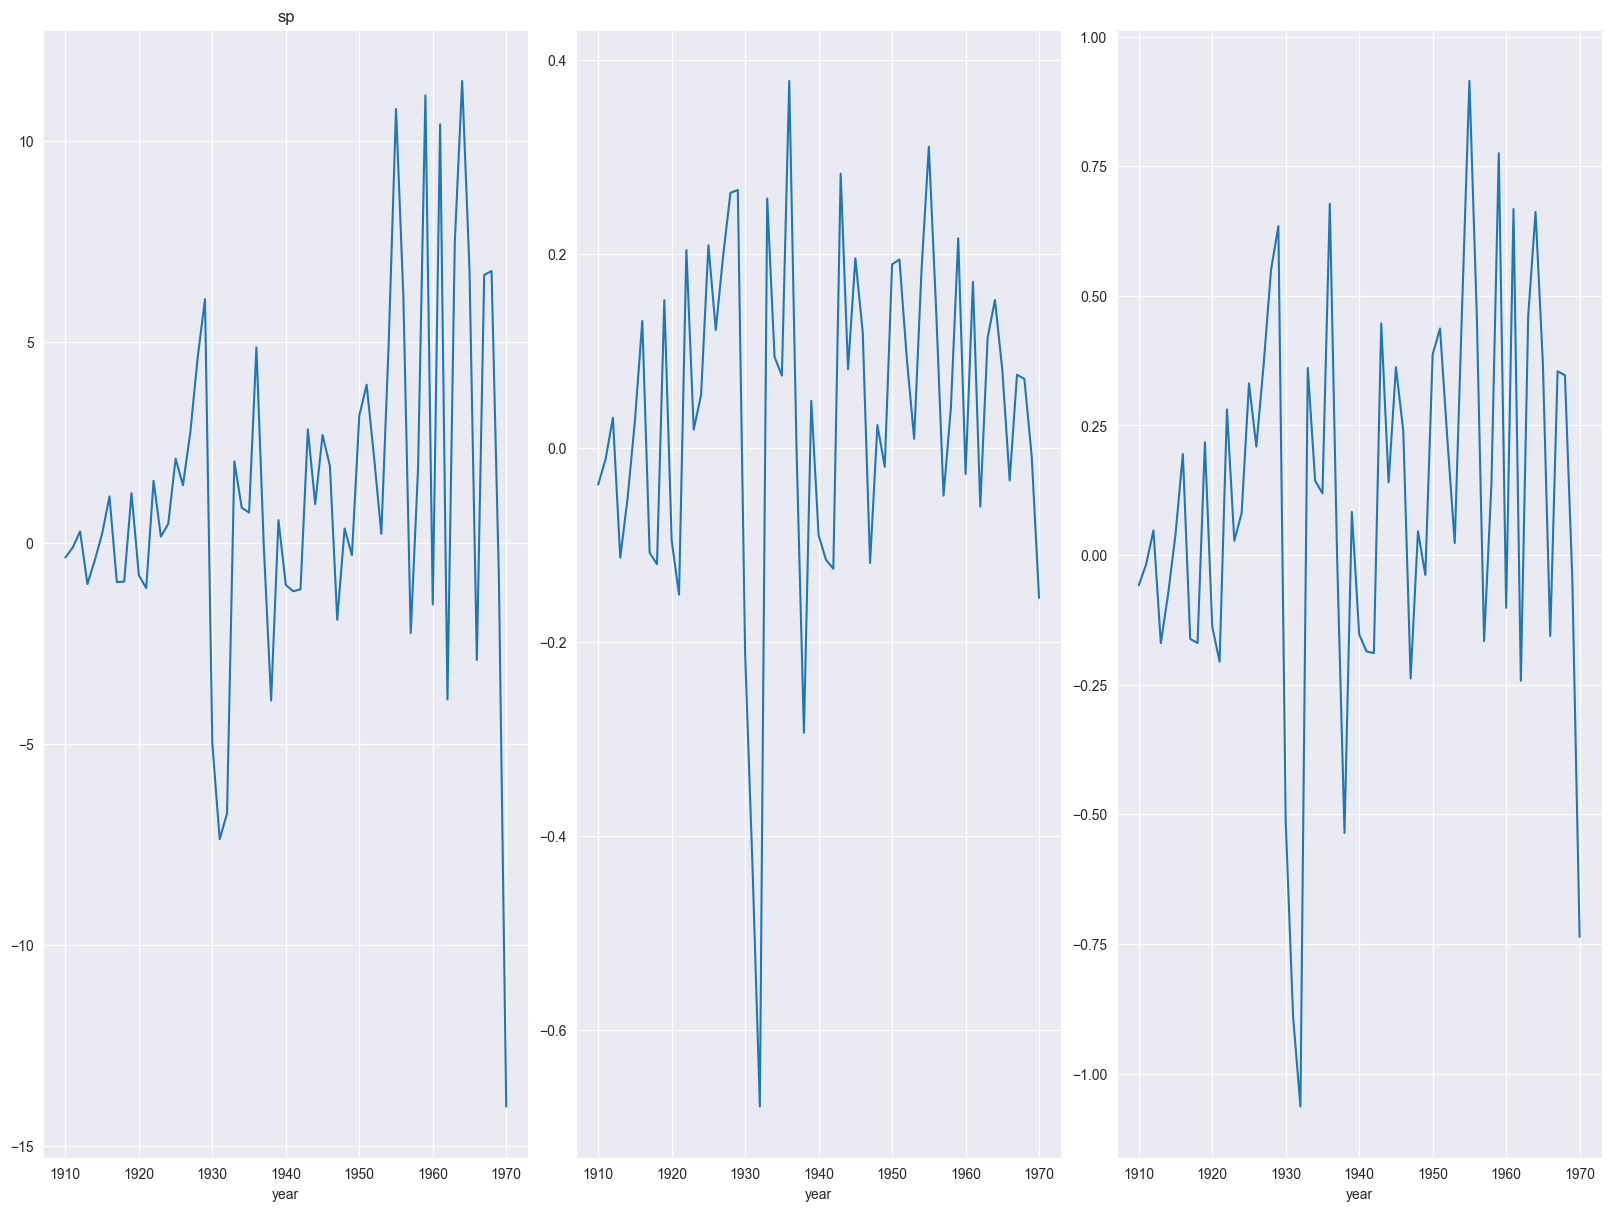

In [79]:
cols = df.columns


for i, col in enumerate(cols):

    fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize = (16, 12))
    axs = axs.flatten()
    (df[col] - df[col].shift(1)).plot(ax=axs[0])
    (np.log(df[col]) - np.log(df[col]).shift(1)).plot(ax=axs[1])
    (np.sqrt(df[col]) - np.sqrt(df[col]).shift(1)).plot(ax=axs[2])
    axs[0].set_title(col)
    plt.show()


plt.show()

In [80]:
import statsmodels.api as sm


for col in df.columns:
    df[f'{col}_diff'] = df[col] - df[col].shift(1)
    df[f'log{col}_diff'] = np.log(df[col]) - np.log(df[col]).shift(1)
    df[f'sqrt{col}_diff'] = np.sqrt(df[col]) - np.sqrt(df[col]).shift(1)

idx = df.isnull()
df = df[~idx]
df

/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2271369548.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{col}_diff'] = df[col] - df[col].shift(1)
/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2271369548.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'log{col}_diff'] = np.log(df[col]) - np.log(df[col]).shift(1)
/var/folders/65/kfyt6zd17rnft11mhd0p3ysc0000gn/T/ipykernel_44889/2271369548.py:7: SettingWithCopyWarning: 
A value is trying to be set on a cop

,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,wg.r,...,sqrtM_diff,vel_diff,logvel_diff,sqrtvel_diff,bnd_diff,logbnd_diff,sqrtbnd_diff,sp_diff,logsp_diff,sqrtsp_diff
year,,,,,,,,,,,,,,,,,,,,,
1909,116.8,33400.0,1291.0,10.0,35072.0,5.1,29.1,28.0,599.0,21.39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1910,120.1,35300.0,1300.0,10.6,35762.0,5.9,29.9,29.0,651.0,22.45,...,0.091498,-0.02,-0.009174,-0.006773,0.03,0.007926,0.007710,-0.36,-0.037780,-0.058310
1911,123.2,35800.0,1312.0,10.2,36179.0,6.7,29.7,29.0,632.0,21.79,...,0.105262,-0.10,-0.047179,-0.034343,0.10,0.025975,0.025483,-0.11,-0.011834,-0.018040
1912,130.2,39400.0,1366.0,11.7,37433.0,4.6,30.9,30.0,651.0,21.70,...,0.132071,0.05,0.023867,0.017273,0.00,0.000000,0.000000,0.29,0.030903,0.047333
1913,131.4,39600.0,1351.0,12.5,38298.0,4.3,31.1,29.7,689.0,23.20,...,0.076376,0.03,0.014052,0.010266,0.10,0.025318,0.025158,-1.02,-0.113203,-0.169879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,68.34,...,0.641351,0.04,0.022990,0.015162,0.40,0.087969,0.093784,-2.91,-0.033561,-0.156254
1967,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,68.80,...,0.665449,-0.04,-0.022990,-0.015162,0.20,0.041243,0.045410,6.67,0.075322,0.354379
1968,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,70.51,...,0.800405,0.00,0.000000,0.000000,0.98,0.180637,0.210300,6.77,0.071058,0.346774


In [81]:
df = df.reset_index()

,year,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,...,sqrtM_diff,vel_diff,logvel_diff,sqrtvel_diff,bnd_diff,logbnd_diff,sqrtbnd_diff,sp_diff,logsp_diff,sqrtsp_diff
0,1909,116.8,33400.0,1291.0,10.0,35072.0,5.1,29.1,28.0,599.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1910,120.1,35300.0,1300.0,10.6,35762.0,5.9,29.9,29.0,651.0,...,0.091498,-0.02,-0.009174,-0.006773,0.03,0.007926,0.007710,-0.36,-0.037780,-0.058310
2,1911,123.2,35800.0,1312.0,10.2,36179.0,6.7,29.7,29.0,632.0,...,0.105262,-0.10,-0.047179,-0.034343,0.10,0.025975,0.025483,-0.11,-0.011834,-0.018040
3,1912,130.2,39400.0,1366.0,11.7,37433.0,4.6,30.9,30.0,651.0,...,0.132071,0.05,0.023867,0.017273,0.00,0.000000,0.000000,0.29,0.030903,0.047333
4,1913,131.4,39600.0,1351.0,12.5,38298.0,4.3,31.1,29.7,689.0,...,0.076376,0.03,0.014052,0.010266,0.10,0.025318,0.025158,-1.02,-0.113203,-0.169879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1966,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,...,0.641351,0.04,0.022990,0.015162,0.40,0.087969,0.093784,-2.91,-0.033561,-0.156254
58,1967,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,...,0.665449,-0.04,-0.022990,-0.015162,0.20,0.041243,0.045410,6.67,0.075322,0.354379
59,1968,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,...,0.800405,0.00,0.000000,0.000000,0.98,0.180637,0.210300,6.77,0.071058,0.346774
60,1969,724.7,929095.0,3577.0,110.7,81408.0,3.5,128.2,109.8,7775.0,...,0.610730,0.01,0.005797,0.003807,0.61,0.097913,0.122183,-0.86,-0.008751,-0.043377


In [83]:
df = df.dropna()

In [84]:
df

,year,gnp.r,gnp.n,gnp.pc,ip,emp,ur,gnp.p,cpi,wg.n,...,sqrtM_diff,vel_diff,logvel_diff,sqrtvel_diff,bnd_diff,logbnd_diff,sqrtbnd_diff,sp_diff,logsp_diff,sqrtsp_diff
1,1910,120.1,35300.0,1300.0,10.6,35762.0,5.9,29.9,29.0,651.0,...,0.091498,-0.02,-0.009174,-0.006773,0.03,0.007926,0.007710,-0.36,-0.037780,-0.058310
2,1911,123.2,35800.0,1312.0,10.2,36179.0,6.7,29.7,29.0,632.0,...,0.105262,-0.10,-0.047179,-0.034343,0.10,0.025975,0.025483,-0.11,-0.011834,-0.018040
3,1912,130.2,39400.0,1366.0,11.7,37433.0,4.6,30.9,30.0,651.0,...,0.132071,0.05,0.023867,0.017273,0.00,0.000000,0.000000,0.29,0.030903,0.047333
4,1913,131.4,39600.0,1351.0,12.5,38298.0,4.3,31.1,29.7,689.0,...,0.076376,0.03,0.014052,0.010266,0.10,0.025318,0.025158,-1.02,-0.113203,-0.169879
5,1914,125.6,38600.0,1267.0,11.7,37559.0,7.9,31.4,30.1,696.0,...,0.082350,-0.27,-0.134196,-0.095157,0.10,0.024693,0.024846,-0.43,-0.051850,-0.074656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1966,658.1,749857.0,3349.0,98.0,76018.0,3.8,113.9,97.2,6643.0,...,0.641351,0.04,0.022990,0.015162,0.40,0.087969,0.093784,-2.91,-0.033561,-0.156254
58,1967,675.2,793927.0,3399.0,100.0,77818.0,3.8,117.6,100.0,6880.0,...,0.665449,-0.04,-0.022990,-0.015162,0.20,0.041243,0.045410,6.67,0.075322,0.354379
59,1968,706.6,864202.0,3522.0,105.8,79455.0,3.6,122.3,104.2,7347.0,...,0.800405,0.00,0.000000,0.000000,0.98,0.180637,0.210300,6.77,0.071058,0.346774
60,1969,724.7,929095.0,3577.0,110.7,81408.0,3.5,128.2,109.8,7775.0,...,0.610730,0.01,0.005797,0.003807,0.61,0.097913,0.122183,-0.86,-0.008751,-0.043377


### Fitting First Regression Model

In [99]:
y_cols = ['sp_diff', 'logsp_diff', 'sqrtsp_diff']
X = df.drop(y_cols, axis = 1)
y1 = df[y_cols[1]]
y1

1    -0.037780
2    -0.011834
3     0.030903
4    -0.113203
5    -0.051850
        ...   
57   -0.033561
58    0.075322
59    0.071058
60   -0.008751
61   -0.154662
Name: logsp_diff, Length: 61, dtype: float64

In [102]:
lr = sm.OLS(y1, X)
model = lr.fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             logsp_diff   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.949
Method:                 Least Squares   F-statistic:                              22.17
Date:                Thu, 09 Apr 2026   Prob (F-statistic):                    0.000137
Time:                        22:09:08   Log-Likelihood:                          174.88
No. Observations:                  61   AIC:                                     -241.8
Df Residuals:                       7   BIC:                                     -127.8
Df Model:                          54                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

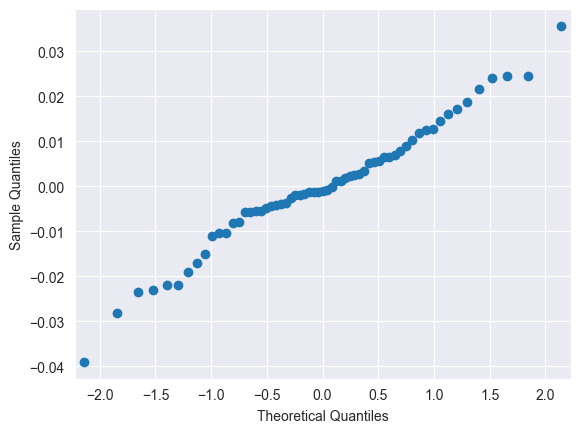

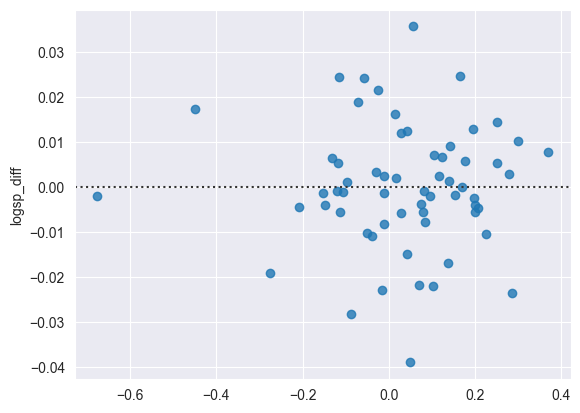

In [106]:
sm.qqplot(model.resid)
plt.show()

sns.residplot(x=model.fittedvalues, y=y1)
plt.show()

In [110]:
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
cooks_d

array([1.16013386e-01, 9.55351798e-03, 2.48948603e-02, 3.40060563e-01,
       9.41407815e-01, 2.05399230e-01, 8.95928707e-01, 1.68177085e-01,
       6.63818466e-01, 2.01916050e+00, 4.85194956e-01, 6.99037643e-01,
       1.28243128e+00, 2.80050417e-02, 9.54519631e-02, 1.53543267e-01,
       1.58780390e-01, 9.69108249e-03, 5.01185844e-02, 2.52686619e-01,
       7.98202192e-03, 2.58696224e-01, 2.90980868e-02, 5.39783129e-02,
       7.34080537e-03, 5.55629269e-03, 3.36506643e-03, 5.06864847e-02,
       1.55910180e+00, 1.20173569e-01, 1.13744334e-01, 2.77149097e-01,
       1.05708287e-01, 6.84473428e-02, 1.87069652e-02, 1.84550302e+00,
       2.85764802e-01, 1.65900686e-01, 2.22465031e-02, 2.86975822e-01,
       8.42746374e-01, 3.93937346e-01, 4.43319558e-01, 8.40701514e-02,
       6.68439954e-03, 1.37370488e-01, 4.50450313e-03, 2.83499920e-02,
       2.28858019e-02, 8.34844530e-03, 4.27011262e-02, 2.50021138e-06,
       2.66398481e-02, 1.40123684e-01, 5.26904613e-02, 4.95835232e-02,
      

In [117]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

variance_inflation_factor(X, 15)

np.float64(916778.1263329708)

### Regularisation

In [129]:
X.columns
X = X.drop(['year', 'gnp.r', 'gnp.n', 'gnp.pc', 'ip', 'emp', 'ur', 'gnp.p', 'cpi',
       'wg.n', 'wg.r', 'M', 'vel', 'bnd', 'sp'], axis=1)

In [130]:
X

,gnp.r_diff,loggnp.r_diff,sqrtgnp.r_diff,gnp.n_diff,loggnp.n_diff,sqrtgnp.n_diff,gnp.pc_diff,loggnp.pc_diff,sqrtgnp.pc_diff,ip_diff,...,sqrtwg.r_diff,M_diff,logM_diff,sqrtM_diff,vel_diff,logvel_diff,sqrtvel_diff,bnd_diff,logbnd_diff,sqrtbnd_diff
1,3.3,0.027862,0.151610,1900.0,0.055327,5.126273,9.0,0.006947,0.125024,0.6,...,0.113211,0.66,0.050741,0.091498,-0.02,-0.009174,-0.006773,0.03,0.007926,0.007710
2,3.1,0.025484,0.140535,500.0,0.014065,1.325937,12.0,0.009188,0.166028,-0.4,...,-0.070167,0.78,0.056825,0.105262,-0.10,-0.047179,-0.034343,0.10,0.025975,0.025483
3,7.0,0.055263,0.310972,3600.0,0.095818,9.285453,54.0,0.040334,0.737897,1.5,...,-0.009650,1.01,0.069087,0.132071,0.05,0.023867,0.017273,0.00,0.000000,0.000000
4,1.2,0.009174,0.052462,200.0,0.005063,0.503155,-15.0,-0.011042,-0.203485,0.8,...,0.158312,0.60,0.038890,0.076376,0.03,0.014052,0.010266,0.10,0.025318,0.025158
5,-5.8,-0.045144,-0.255843,-1000.0,-0.025577,-2.528660,-84.0,-0.064193,-1.161008,-0.8,...,-0.008312,0.66,0.041102,0.082350,-0.27,-0.134196,-0.095157,0.10,0.024693,0.024846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,40.3,0.063192,0.797877,64973.0,0.090633,38.365652,168.0,0.051466,1.470191,8.8,...,0.044271,22.10,0.074458,0.641351,0.04,0.022990,0.015162,0.40,0.087969,0.093784
58,17.1,0.025652,0.331151,44070.0,0.057109,25.082975,50.0,0.014819,0.430398,2.0,...,0.027775,23.80,0.074433,0.665449,-0.04,-0.022990,-0.015162,0.20,0.041243,0.045410
59,31.4,0.045456,0.597338,70275.0,0.084815,38.598842,123.0,0.035548,1.045497,5.8,...,0.102447,29.80,0.086006,0.800405,0.00,0.000000,0.000000,0.98,0.180637,0.210300
60,18.1,0.025293,0.338304,64893.0,0.072404,34.271086,55.0,0.015495,0.461586,4.9,...,0.017845,23.60,0.063224,0.610730,0.01,0.005797,0.003807,0.61,0.097913,0.122183


In [138]:

model = sm.OLS(y1, X)
results = model.fit_regularized(method='elastic_net', alpha=0.5, L1_wt=1.0)
selected_features = results.params[results.params != 0].index
selected_features

Index(['gnp.n_diff', 'gnp.pc_diff', 'emp_diff'], dtype='object')

In [141]:
model = sm.OLS(y1, X[['gnp.n_diff', 'gnp.pc_diff', 'emp_diff']])
model = model.fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             logsp_diff   R-squared (uncentered):                   0.193
Model:                            OLS   Adj. R-squared (uncentered):              0.151
Method:                 Least Squares   F-statistic:                              4.612
Date:                Thu, 09 Apr 2026   Prob (F-statistic):                     0.00582
Time:                        22:24:36   Log-Likelihood:                          24.400
No. Observations:                  61   AIC:                                     -42.80
Df Residuals:                      58   BIC:                                     -36.47
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------